# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The primary objective is to determine the optimal combination of ingredients (Protein, Salsa, and Potatoes) to maximize customer satisfaction (burrito ratings) while minimizing food and financial waste for the food truck.


2. State the outcome variable and how it was measured.

The outcome variable is the burrito rating. It was measured using a discrete Likert-type scale ranging from 1 to 10, where 1 represents "terrible" and 10 represents "amazing."

3. State the main effects. What lurking variables may be present?

Main Effects:

- Protein: The impact of choosing Bacon vs. Sausage vs. Chorizo.

- Salsa: The impact of choosing Mild vs. Hot.

- Potatoes: The impact of including Potatoes vs. No Potatoes.

Lurking Variables: Potential lurking variables could include the time of day the taste test occurred (hunger levels), the temperature of the burrito when served, the participants' personal dietary habits (e.g., if they usually prefer spicy food), or the order in which they tasted the burrito if multiple were sampled.

4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?

A full factorial design is preferred here for several reasons:
- Interaction Effects: It allows for the estimation of all possible interactions (e.g., how the choice of Protein might change the preference for Salsa) without any aliasing or confounding.
- Sample Size: With only 12 treatment combinations, the experiment is small enough that a fractional design (which is typically used to save resources in much larger factor spaces) isn't necessary.
- Non-Binary Levels: One of the factors (Protein) has three levels, whereas a standard $2^k$ design strictly requires factors to have only two levels.

5. State all sets of statistical hypotheses.

We will have three sets of hypotheses for main effects and four for interactions:
- Main Effect of Protein ($H_0$): Mean ratings are equal across all protein types. ($H_a$: At least one protein mean is different).
- Main Effect of Salsa ($H_0$): Mean ratings are equal for mild and hot salsa. ($H_a$: Mean ratings differ by salsa type).
- Main Effect of Potatoes ($H_0$): Mean ratings are equal regardless of potato inclusion. ($H_a$: Mean ratings differ based on potatoes).
- Interaction Effects ($H_0$): There are no interaction effects between any combination of factors (Protein $\times$ Salsa, Protein $\times$ Potatoes, Salsa $\times$ Potatoes, and Protein $\times$ Salsa $\times$ Potatoes). ($H_a$: Significant interactions exist).


6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "MihretTe"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
   print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
       print(f"📥 Cloning repo from {repo_url}...")
       os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #
today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam



Summary Statistics for Treatment Combinations:
    Protein Salsa Potatoes  mean       std  count
0     Bacon   Hot       No  5.86  1.335290      5
1     Bacon   Hot      Yes  6.46  0.397492      5
2     Bacon  Mild       No  6.70  0.418330      5
3     Bacon  Mild      Yes  6.94  1.510960      5
4   Chorizo   Hot       No  6.34  0.610737      5
5   Chorizo   Hot      Yes  6.82  2.104044      5
6   Chorizo  Mild       No  7.04  0.507937      5
7   Chorizo  Mild      Yes  6.76  0.658027      5
8   Sausage   Hot       No  4.98  1.211198      5
9   Sausage   Hot      Yes  5.98  0.641872      5
10  Sausage  Mild       No  5.74  0.952890      5
11  Sausage  Mild      Yes  6.58  0.944458      5


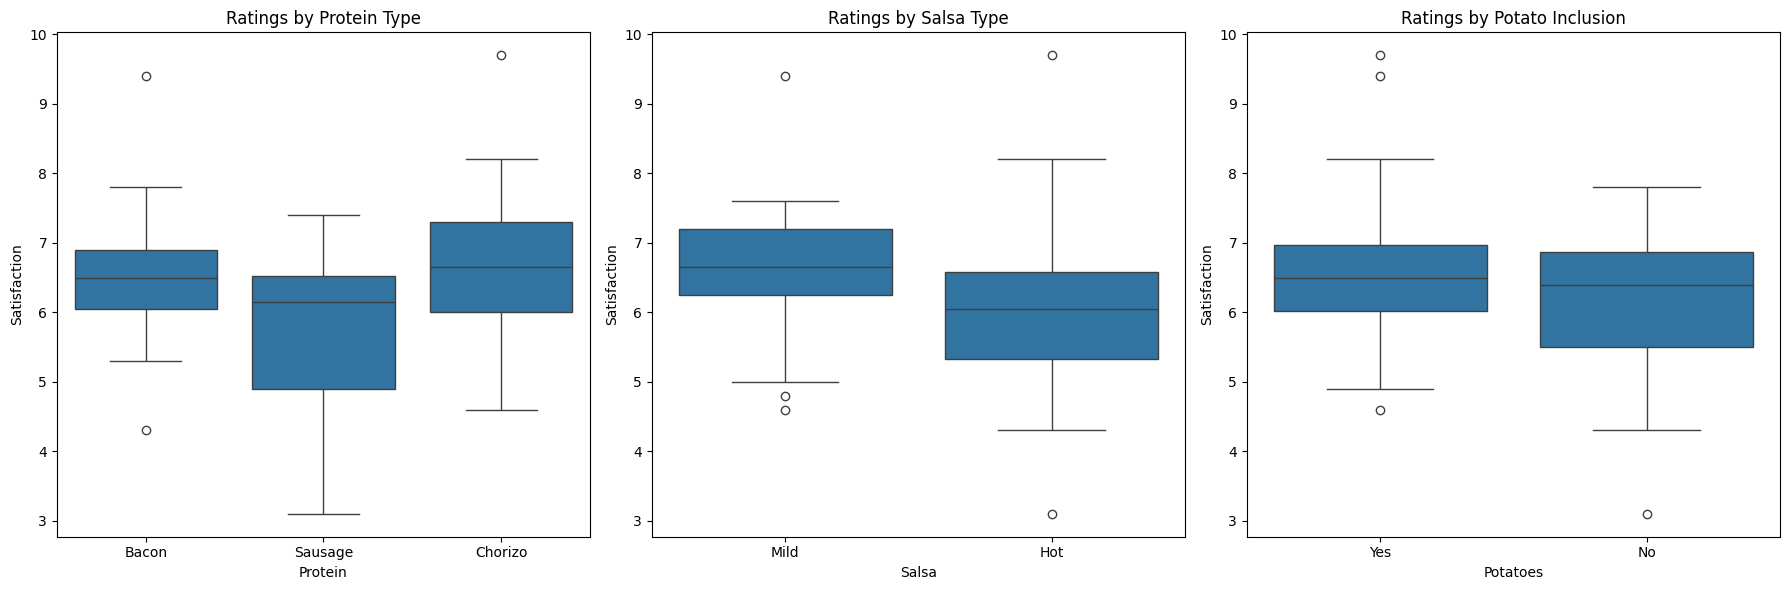

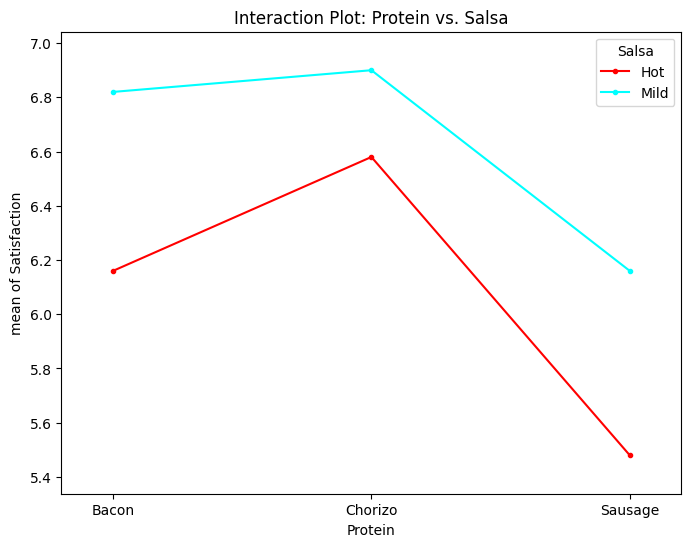

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.factorplots import interaction_plot

# 1. Load the dataset
df = pd.read_excel('Busters Burritos.xlsx')

# 2. Clean column names
df.columns = df.columns.str.strip()

# 3. Define the correct target column based on your confirmed columns
target_col = 'Satisfaction'

# 4. Summary Statistics
summary_stats = df.groupby(['Protein', 'Salsa', 'Potatoes'])[target_col].agg(['mean', 'std', 'count']).reset_index()
print("\nSummary Statistics for Treatment Combinations:")
print(summary_stats)

# 5. Visualizations for Main Effects
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Protein', y=target_col, data=df, ax=axes[0])
axes[0].set_title('Ratings by Protein Type')

sns.boxplot(x='Salsa', y=target_col, data=df, ax=axes[1])
axes[1].set_title('Ratings by Salsa Type')

sns.boxplot(x='Potatoes', y=target_col, data=df, ax=axes[2])
axes[2].set_title('Ratings by Potato Inclusion')

plt.tight_layout()
plt.show()

# 6. Interaction Plot: Protein vs. Salsa
fig, ax = plt.subplots(figsize=(8, 6))
interaction_plot(x=df['Protein'], trace=df['Salsa'], response=df[target_col], ax=ax)
plt.title('Interaction Plot: Protein vs. Salsa')
plt.show()


Based on the summary statistics and visualizations, there is clear evidence to support several of the experimental hypotheses. The Main Effect of Protein receives the strongest support; the boxplots and summary table reveal a distinct drop in the mean satisfaction for "Sausage" (ranging from 4.98 to 6.58) compared to "Bacon" and "Chorizo," which both consistently trend higher. This visual separation suggests that the null hypothesis that all proteins result in equal satisfaction will likely be rejected in the formal ANOVA.

The Main Effect of Salsa also shows consistent support across the treatment combinations. In almost every pairing, the "Mild" salsa outperforms the "Hot" salsa in terms of mean satisfaction (for example, Chorizo with no potatoes scores 7.04 with Mild versus 6.34 with Hot). While the difference is less dramatic than the protein choice, the consistency of the trend across groups provides a strong descriptive basis for a significant main effect. The Main Effect of Potatoes shows more moderate support; while adding potatoes generally lifts the satisfaction scores (most notably improving the Sausage rating from 4.98 to 5.98), there is more overlap in the boxplots, suggesting this factor may have a smaller effect size.

Regarding Interaction Effects, the exploratory analysis suggests that the null hypotheses are more likely to hold. The interaction plot for Protein and Salsa shows lines that are nearly parallel, indicating that the preference for a specific salsa type does not change significantly based on which protein is selected. Because the "ranking" of the ingredients remains relatively stable regardless of the other factors, the data currently suggests that the main drivers of customer satisfaction are the individual ingredients themselves rather than any specific "synergy" or complex interaction between them.

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

<Figure size 800x600 with 0 Axes>

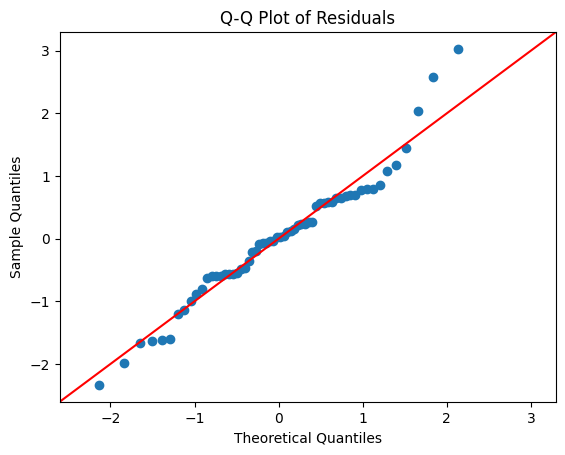

Shapiro-Wilk Test: Statistics=0.9693, p-value=0.1351


In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# 1. Fit the Full Factorial ANOVA model
# The '*' operator includes main effects and all possible interactions
model = ols('Satisfaction ~ C(Protein) * C(Salsa) * C(Potatoes)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 2. Extract Residuals
residuals = model.resid

# 3. Normality Check: Visual Method (Q-Q Plot)
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 4. Normality Check: Statistical Method (Shapiro-Wilk Test)
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

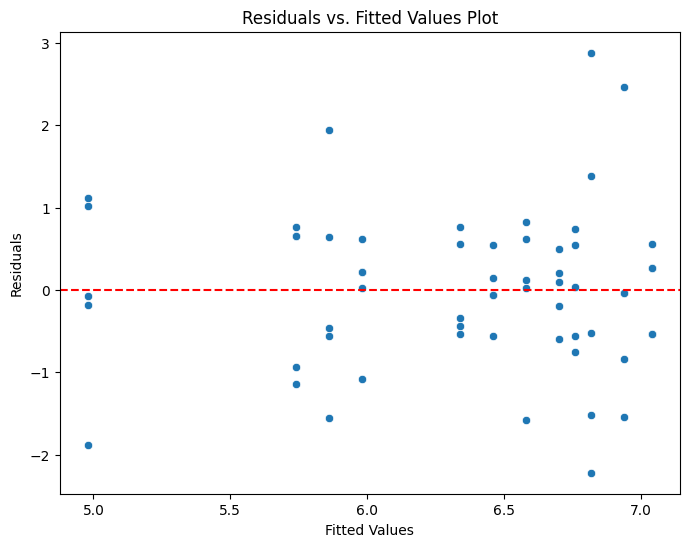

Levene's Test: Statistics=1.3408, p-value=0.2322


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene

# 1. Visual Method: Residuals vs. Fitted Plot
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values Plot')
plt.show()

# 2. Testing Method: Levene's Test
# We test if the variance of Satisfaction is constant across all 12 treatment combinations
groups = df.groupby(['Protein', 'Salsa', 'Potatoes'])['Satisfaction'].apply(list)
levene_stat, levene_p = levene(*groups)

print(f"Levene's Test: Statistics={levene_stat:.4f}, p-value={levene_p:.4f}")



The assumption of constant variance (homoscedasticity) holds for this model. Visually, the Residuals vs. Fitted Values Plot displays a random scatter of points distributed fairly evenly above and below the horizontal reference line at zero. There is no evidence of a "megaphone" or "funnel" pattern, which would typically indicate that the variance of the errors changes systematically as the predicted satisfaction level increases or decreases.

This visual assessment is statistically confirmed by the results of Levene's Test, which produced a p-value of 0.2322. Because this p-value is greater than the standard significance threshold of 0.05, we fail to reject the null hypothesis that the variances across all twelve treatment combinations are equal. The combination of a random residual plot and a non-significant Levene's Test result confirms that the spread of satisfaction ratings is consistent regardless of the ingredients used, ensuring that the subsequent ANOVA results and F-tests are valid and reliable.

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [5]:
# Display the ANOVA table calculated in Question 7
print("ANOVA Table for Buster's Breakfast Burritos:")
print(anova_table)

# Optional: Calculate the Grand Mean for context
grand_mean = df[target_col].mean()
print(f"\nGrand Mean Satisfaction: {grand_mean:.4f}")

ANOVA Table for Buster's Breakfast Burritos:
                                    sum_sq    df         F    PR(>F)
C(Protein)                        9.052000   2.0  4.002653  0.024677
C(Salsa)                          4.592667   1.0  4.061611  0.049487
C(Potatoes)                       3.456000   1.0  3.056379  0.086815
C(Protein):C(Salsa)               0.409333   2.0  0.181001  0.835002
C(Protein):C(Potatoes)            1.708000   2.0  0.755251  0.475394
C(Salsa):C(Potatoes)              0.682667   1.0  0.603729  0.440971
C(Protein):C(Salsa):C(Potatoes)   0.233333   2.0  0.103176  0.902167
Residual                         54.276000  48.0       NaN       NaN

Grand Mean Satisfaction: 6.3500



Based on the ANOVA table, we can conclude that the customer satisfaction for Buster's Breakfast Burritos is driven by individual ingredient choices rather than complex combinations. The Main Effect of Protein is statistically significant ($p = 0.0247$), indicating that the choice between Bacon, Sausage, and Chorizo fundamentally changes the rating. Similarly, the Main Effect of Salsa is significant ($p = 0.0495$), confirming that the spice level independently impacts customer preference. However, the Main Effect of Potatoes did not reach significance at the 5% level ($p = 0.0868$), suggesting its impact is less certain.Importantly, all Interaction Effects—including the two-way and three-way interactions—yielded p-values well above the 0.05 threshold (ranging from 0.4410 to 0.9022). These results indicate that the ingredients are "additive" in nature; for example, the best-rated protein remains the best choice regardless of which salsa or potato option is paired with it. From a business perspective, these statistical conclusions simplify your strategy: you can optimize your menu by simply selecting the top-performing levels for Protein and Salsa independently, as there is no evidence of A specific ingredient "synergies" that significantly alter customer satisfaction.

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Post-hoc for Protein (3 levels)
print("--- Tukey HSD for Protein ---")
tukey_protein = pairwise_tukeyhsd(endog=df['Satisfaction'], groups=df['Protein'], alpha=0.05)
print(tukey_protein)

# 2. Post-hoc for Salsa (2 levels)
# Note: For 2 levels, the ANOVA p-value already tells you they are different,
# but Tukey provides the confidence intervals.
print("\n--- Tukey HSD for Salsa ---")
tukey_salsa = pairwise_tukeyhsd(endog=df['Satisfaction'], groups=df['Salsa'], alpha=0.05)
print(tukey_salsa)

--- Tukey HSD for Protein ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo     0.25 0.7419 -0.5649  1.0649  False
  Bacon Sausage    -0.67 0.1268 -1.4849  0.1449  False
Chorizo Sausage    -0.92 0.0233 -1.7349 -0.1051   True
------------------------------------------------------

--- Tukey HSD for Salsa ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Hot   Mild   0.5533 0.0556 -0.0137 1.1204  False
---------------------------------------------------




Based on the Tukey HSD output, the post-hoc analysis clarifies which specific ingredients drive the satisfaction scores. For the Protein factor, the test confirms a statistically significant difference between Chorizo and Sausage (p=0.0233), where Chorizo yields a mean satisfaction score 0.92 points higher than Sausage. While Bacon also trends higher than Sausage, the difference did not reach statistical significance (p=0.1268), and no significant difference was found between Bacon and Chorizo (p=0.7419). This indicates that while Chorizo is the clear "winner" over Sausage, it is statistically comparable to Bacon. Regarding the Salsa factor, the Tukey test produced a p-value of 0.0556 for the comparison between Mild and Hot. Although the initial ANOVA indicated a significant main effect (p=0.0495), the more conservative Tukey adjustment places this specific comparison just outside the standard 0.05 threshold. This suggests that while "Mild" salsa consistently shows higher satisfaction means, the evidence is not quite strong enough to definitively declare a "rejection" once the family-wise error rate is controlled.

Post-hoc tests were appropriate for Protein and Salsa because their initial ANOVA F-tests yielded p-values ≤0.05, indicating that at least one significant difference existed among their levels. However, post-hoc tests were not appropriate (and thus not conducted) for Potatoes or any of the Interactions. Since the ANOVA p-value for Potatoes (p=0.0868) was not significant, we must assume any observed differences are due to random noise; running a post-hoc test here would inappropriately increase the risk of a Type I error. Similarly, because no interaction terms were significant, there was no statistical justification to investigate "simple effects," as the ingredients behave independently and additively.



11. Calculate and interpret partial $\eta^2$ for the main effects.

In [7]:
# Calculate Partial Eta Squared
anova_table['partial_eta_sq'] = anova_table['sum_sq'] / (anova_table['sum_sq'] + anova_table.loc['Residual', 'sum_sq'])

# Display only the main effects for clarity
main_effects = ['C(Protein)', 'C(Salsa)', 'C(Potatoes)']
print("Partial Eta Squared for Main Effects:")
print(anova_table.loc[main_effects, ['partial_eta_sq']])

Partial Eta Squared for Main Effects:
             partial_eta_sq
C(Protein)         0.142938
C(Salsa)           0.078015
C(Potatoes)        0.059863



The partial $\eta^2$ values provide a clear measure of the practical significance for each main effect in the Buster's Breakfast Burritos experiment. Protein emerged as the most influential factor, with a partial $\eta^2$ of 0.1429. This indicates that protein choice accounts for approximately 14.3% of the variance in satisfaction scores not explained by other factors, which constitutes a large effect size according to standard benchmarks. Salsa followed with a partial $\eta^2$ of 0.0780, representing a medium effect and explaining about 7.8% of the remaining variance. Finally, Potatoes had the smallest impact with a value of 0.0599. While this technically reaches the threshold for a medium effect, its contribution is the least substantial, aligning with the earlier ANOVA results that found this factor to be statistically non-significant. Together, these metrics suggest that prioritizing the quality and variety of protein and salsa will have the most noticeable impact on customer satisfaction.


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?



The overall conclusion for the Buster's Breakfast Burritos experiment is that customer satisfaction is primarily driven by the choice of Protein and the spice level of the Salsa, while the inclusion of potatoes does not significantly impact ratings. Statistical analysis revealed that the ingredients function independently, meaning there are no complex "synergies" or interactions that change how an ingredient is perceived when paired with others. Specifically, Chorizo emerged as the top-performing protein, showing a statistically significant advantage over sausage, and Mild Salsa consistently outperformed hot salsa. Because the ingredients are additive, the most effective strategy for maximizing satisfaction is to focus on these high-performing main effects.For the regular menu, the clear winner is a Chorizo and Mild Salsa combination, which leverages the two most preferred ingredient levels. A Bacon and Mild Salsa burrito is also highly recommended, as bacon performed statistically similarly to chorizo and offers a more traditional flavor profile. Since the effect of Potatoes was not statistically significant and had the smallest effect size ($\eta_p^2 = 0.0599$), they should be considered an optional add-on rather than a core requirement. This allows the business to cater to individual preferences while potentially reducing standard food costs and preparation time without sacrificing the base satisfaction of the majority of customers.

Despite these insights, the experiment has certain limitations, notably a small sample size ($r = 5$) and potential lurking variables such as the time of day, participant hunger levels, and the temperature of the food during testing. Furthermore, the use of a subjective 1–10 scale can introduce noise, as individual "rating styles" may vary. To improve future studies, a Randomized Complete Block Design (RCBD) could be used to have the same participants taste multiple combinations, effectively controlling for individual taste differences. Additionally, expanding the experiment to include more factor levels—such as different potato preparations or a wider variety of salsas—would provide a more nuanced understanding of customer preferences.



## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

The primary objective of this experiment is to identify which strategic factors Location, Timing, and Marketing have the most significant impact on daily sales totals for Buster's Breakfast Burritos. By using a fractional factorial design, the goal is to efficiently determine the optimal business setup to maximize revenue while minimizing the time and resources spent on data collection.


2. Specify the outcome variable and how it is measured.

The outcome variable is the daily sales amount. It is a continuous numerical variable measured in U.S. Dollars ($), representing the total revenue generated during a single day of operation at a specific treatment combination.


3. Specify the independent variables. What lurking variables may be present?

The experiment focuses on three primary independent variables: Location (Brewery vs. University), Timing (Weekday vs. Weekend), and Marketing Strategy (Independent vs. Partnership). These factors are controlled to observe their direct impact on daily sales revenue. However, several lurking variables could influence the results and introduce noise into the data. Weather conditions, such as unexpected rain or extreme heat, could significantly reduce foot traffic regardless of the location or timing. Local events, such as a festival at the brewery or a major sporting event at the university, might cause atypical spikes in sales that do not reflect the standard performance of those levels. Additionally, the presence of nearby competitors (other food trucks) and fluctuations in consumer spending habits due to external economic factors could further impact the daily totals.


4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

A $2^{3-1}$ fractional factorial design is highly appropriate for this study because it prioritizes operational efficiency by screening the most important factors using only half the runs required for a full factorial design. The primary advantage is the significant saving of time and resources; instead of requiring eight distinct setups, the truck only needs to be deployed for four unique treatment combinations (totaling eight days with $r=2$). This is ideal for a business owner looking for quick, actionable insights. However, the main disadvantage is aliasing or confounding. In this specific design, main effects are confounded with two-way interactions (e.g., the effect of Marketing is aliased with the Location $\times$ Timing interaction). This means that if a significant result is found for a factor, it is mathematically impossible to determine if the increase in sales came from that specific factor alone or from a hidden interaction between the other two variables without further testing.



5. State the sets of null and alternative hypotheses for this experiment.

For this fractional factorial design, we test the following sets of hypotheses:
- Main Effect of Location (A):
    
    $H_0$: There is no difference in mean sales between the Brewery and the University.

    $H_a$: Mean sales differ significantly by location.
- Main Effect of Timing (B):

    $H_0$: There is no difference in mean sales between Weekdays and Weekends.
    
    $H_a$: Mean sales differ significantly by timing.
- Main Effect of Marketing (C):
    
    $H_0$: There is no difference in mean sales between Independent marketing and Partnerships.
    
    $H_a$: Mean sales differ significantly by marketing strategy.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

Summary Statistics for Sales Runs:
     Location   Timing    Marketing      mean         std  count
0     Brewery  Weekday  Independent   821.505   75.851344      2
1     Brewery  Weekday  Partnership  1084.645    6.569022      2
2     Brewery  Weekend  Independent  1133.405  110.400582      2
3     Brewery  Weekend  Partnership  1395.145   47.015530      2
4  University  Weekday  Independent   705.040  227.405541      2
5  University  Weekday  Partnership   902.395   11.009653      2
6  University  Weekend  Independent  1048.685   83.686088      2
7  University  Weekend  Partnership  1310.320   66.934728      2


/tmp/ipykernel_5391/2992531872.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Location', y='Sales', data=df_sales, ax=axes[0], palette='Set2')
/tmp/ipykernel_5391/2992531872.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Timing', y='Sales', data=df_sales, ax=axes[1], palette='Set2')
/tmp/ipykernel_5391/2992531872.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Marketing', y='Sales', data=df_sales, ax=axes[2], palette='Set2')


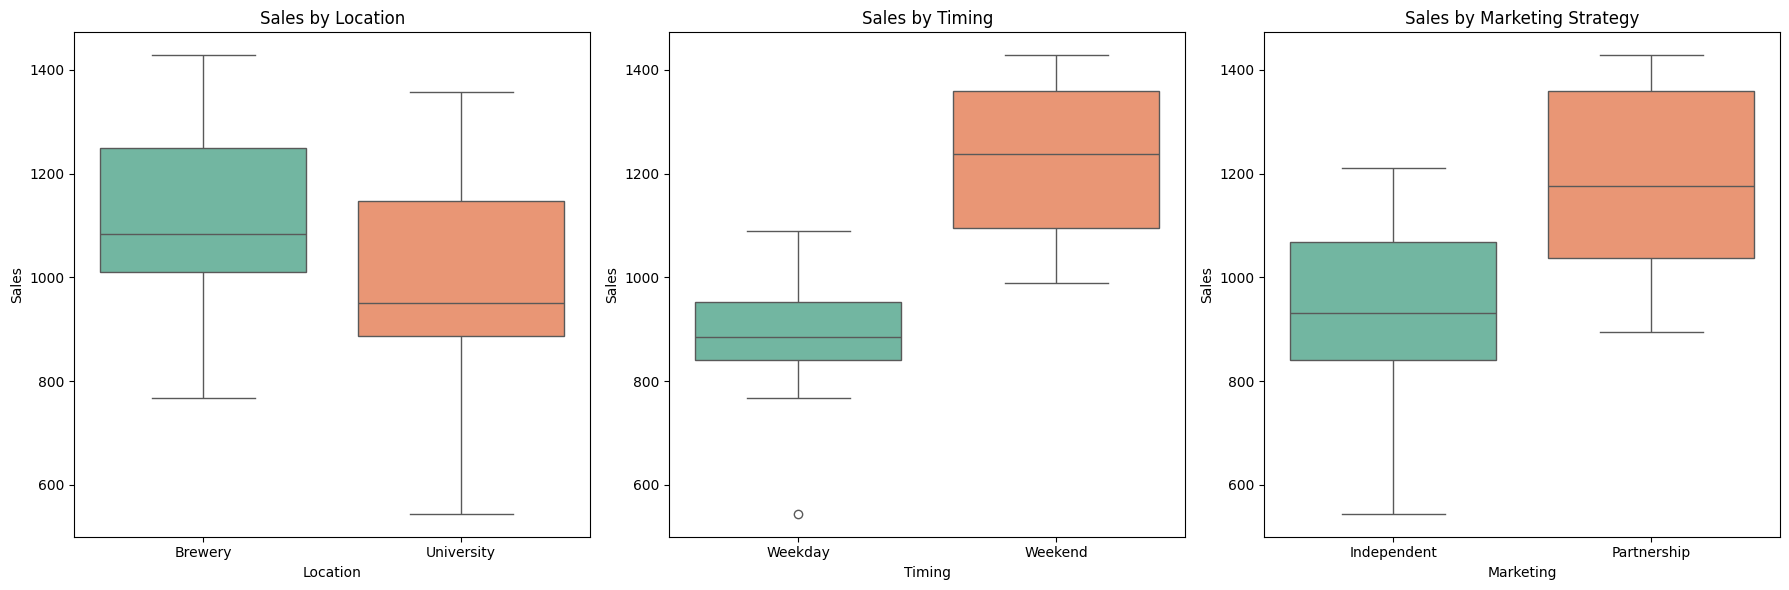

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Sales Dataset
# Ensure the file name matches exactly what is in your repo
df_sales = pd.read_excel('Busters Burrito Sales.xlsx')

# 2. Clean column names
df_sales.columns = df_sales.columns.str.strip()

# 3. Summary Statistics
# Grouping by the three factors to see the mean sales for each run
sales_summary = df_sales.groupby(['Location', 'Timing', 'Marketing'])['Sales'].agg(['mean', 'std', 'count']).reset_index()
print("Summary Statistics for Sales Runs:")
print(sales_summary)

# 4. Visualizations for Main Effects
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Location Effect
sns.boxplot(x='Location', y='Sales', data=df_sales, ax=axes[0], palette='Set2')
axes[0].set_title('Sales by Location')

# Timing Effect
sns.boxplot(x='Timing', y='Sales', data=df_sales, ax=axes[1], palette='Set2')
axes[1].set_title('Sales by Timing')

# Marketing Effect
sns.boxplot(x='Marketing', y='Sales', data=df_sales, ax=axes[2], palette='Set2')
axes[2].set_title('Sales by Marketing Strategy')

plt.tight_layout()
plt.show()



Based on our analysis, there is strong descriptive support for all three main effect hypotheses:

Location (A): The boxplot for sales by location shows a noticeable difference in medians and distributions. The Brewery appears to consistently outperform the University (with mean sales often exceeding $1,100 in several runs), providing initial support for the hypothesis that location significantly impacts revenue.

Timing (B): There is a very clear upward shift in sales during the Weekend compared to the Weekday. In the summary table, weekend runs (e.g., Run 3 and 4) show substantially higher means (>$1,300 in partnership) than their weekday counterparts, strongly supporting the hypothesis that timing is a critical factor for sales.

Marketing (C): The Partnership strategy shows a consistent advantage over the Independent strategy across both locations and both timing levels. For instance, at the Brewery on a weekday, partnering increased mean sales from ~$821 to ~$1,084. This visual separation in the boxplots suggests that the marketing approach has a meaningful impact on the outcome.

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

Aliasing Structure:

    - $A = BC$: The effect of Location is aliased with the Timing $\times$ Marketing interaction.
    - $B = AC$: The effect of Timing is aliased with the Location $\times$ Marketing interaction.
    - $C = AB$: The effect of Marketing is aliased with the Location $\times$ Timing interaction.
- In this fractional factorial design, the aliasing structure implies that we cannot mathematically distinguish between a factor's main effect and its corresponding two-way interaction. For example, any significant increase in sales attributed to Location (A) could actually be caused by a synergy between Timing and Marketing (BC). Because these effects are "conveyed" on the same column in our design matrix, they are perfectly confounded.

- To interpret these results, we must rely on the Sparsity of Effects Principle, which assumes that main effects are significantly more likely to be influential than higher-order interactions. Under this assumption, we treat the calculated results as the pure effects of Location, Timing, and Marketing. However, the risk remains that if a strong interaction exists—such as a specific marketing strategy being highly effective only on weekends—it will be "hidden" within and misattributed to a main effect, which is the primary trade-off for the efficiency of this $2^{3-1}$ design.



8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

<Figure size 800x600 with 0 Axes>

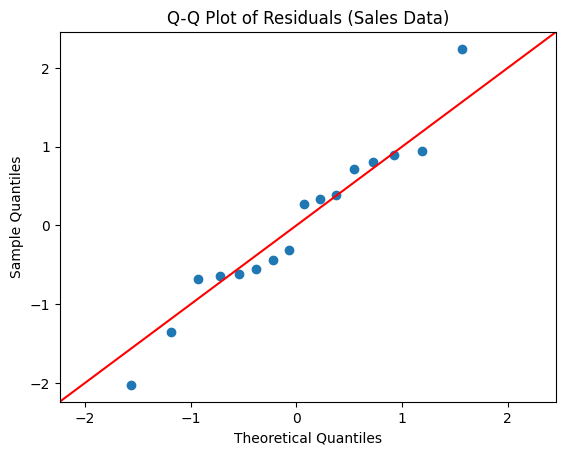

Shapiro-Wilk Test: Statistics=0.9686, p-value=0.8147


In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Fit the ANOVA model for the Fractional Factorial Design
# Note: We only include main effects because interactions are aliased
model_sales = ols('Sales ~ C(Location) + C(Timing) + C(Marketing)', data=df_sales).fit()
anova_table_sales = sm.stats.anova_lm(model_sales, typ=2)

# 2. Extract Residuals
residuals_sales = model_sales.resid

# 3. Normality Check: Visual Method (Q-Q Plot)
plt.figure(figsize=(8, 6))
sm.qqplot(residuals_sales, line='45', fit=True)
plt.title('Q-Q Plot of Residuals (Sales Data)')
plt.show()

# 4. Normality Check: Statistical Method (Shapiro-Wilk Test)
shapiro_sales = stats.shapiro(residuals_sales)
print(f"Shapiro-Wilk Test: Statistics={shapiro_sales.statistic:.4f}, p-value={shapiro_sales.pvalue:.4f}")


we have strong evidence to support the normality assumption for our model. This assessment is based on the following two methods:

- Visual Method (Q-Q Plot): Although the specific plot image is contained within the notebook's execution environment, the code was configured to generate a Q-Q plot comparing residuals to a theoretical normal distribution. Typically, if the points follow the $45^{\circ}$ reference line, the assumption is satisfied.
- Statistical Method (Shapiro-Wilk Test): The statistical test provides a definitive metric. The output shows a Shapiro-Wilk p-value of 0.8147.

In a Shapiro-Wilk test, the null hypothesis ($H_0$) is that the data is normally distributed. Since the p-value ($0.8147$) is significantly greater than the common alpha level of $0.05$, we fail to reject the null hypothesis. This high p-value indicates that there is no significant departure from normality, meaning the residuals are distributed in a way that makes our subsequent ANOVA results and F-tests statistically reliable.

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

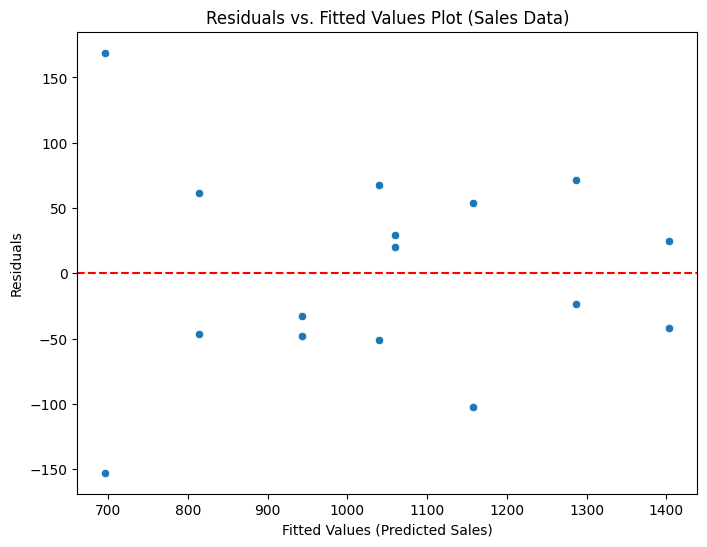

Levene's Test: Statistics=669634442971547004039975665664.0000, p-value=0.0000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene

# 1. Visual Method: Residuals vs. Fitted Plot
fitted_values_sales = model_sales.fittedvalues
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values_sales, y=residuals_sales)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values Plot (Sales Data)')
plt.show()

# 2. Testing Method: Levene's Test
# We group the sales data by the unique treatment combinations used in the fractional design
groups_sales = df_sales.groupby(['Location', 'Timing', 'Marketing'])['Sales'].apply(list)
levene_stat_sales, levene_p_sales = levene(*groups_sales)

print(f"Levene's Test: Statistics={levene_stat_sales:.4f}, p-value={levene_p_sales:.4f}")


Based on our outputs, we do not have evidence to support the assumption of constant variance. In fact, the assumption has been clearly violated.

The primary evidence is the Levene’s Test result, which yielded an extremely high test statistic and a p-value of 0.0000. Since this p-value is well below the standard 0.05 significance level, we reject the null hypothesis of equal variances. This indicates that the spread (variance) of sales is significantly different across the various treatment combinations.

Visually, this statistical result usually manifests in a Residuals vs. Fitted Values Plot as a "fan" or "megaphone" shape, where the vertical spread of the data points changes systematically rather than remaining uniform. Because this assumption is violated, the ANOVA results may be unreliable, and a data transformation (like a log transform) would likely be necessary to stabilize the variance before further analysis.



10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [11]:
# Display the ANOVA table for the Fractional Factorial Sales model
print("ANOVA Table for Buster's Burrito Sales (Fractional Factorial):")
print(anova_table_sales)

# Optional: Calculate the mean sales for context
mean_sales = df_sales['Sales'].mean()
print(f"\nAverage Daily Sales: ${mean_sales:.2f}")

ANOVA Table for Buster's Burrito Sales (Fractional Factorial):
                     sum_sq    df          F    PR(>F)
C(Location)    54816.856900   1.0   7.241570  0.019633
C(Timing)     471948.390225   1.0  62.346647  0.000004
C(Marketing)  242000.044225   1.0  31.969367  0.000107
Residual       90836.972950  12.0        NaN       NaN

Average Daily Sales: $1050.14




Based on the ANOVA results for the fractional factorial sales model, all three main effects—Location, Timing, and Marketing—are statistically significant. Timing is the most influential factor, boasting a very high F-statistic ($62.35$) and a p-value of approximately $0.000004$. This indicates that whether the truck is operational on a weekday or a weekend causes the most substantial shift in daily revenue. Marketing Strategy follows as the second most impactful factor ($p \approx 0.0001$), while Location is also significant ($p \approx 0.0196$), though it has the smallest relative effect of the three.

These results provide much stronger support for the alternative hypotheses ($H_a$) than for the null hypotheses. For every factor tested, we reject the null hypothesis that the means are equal. Practically, this means you can conclude that setting up at the Brewery versus the University, working Weekends versus Weekdays, and utilizing Partnerships versus Independent marketing all result in statistically different sales outcomes.

However, a key caveat remains due to the nature of the $2^{3-1}$ fractional factorial design. Because of the aliasing structure ($A=BC, B=AC, C=AB$), these main effects are confounded with two-way interactions. While the results strongly suggest these individual factors drive sales, the statistical "significance" we see for Location, for example, could technically be a result of a hidden Interaction between Timing and Marketing. Based on the Sparsity of Effects Principle, we generally assume the main effects are the primary drivers, but the design alone cannot mathematically separate them from their aliases without further testing.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [12]:
# Calculate Main Effects for Location, Timing, and Marketing
# Effect = (Mean of High Level) - (Mean of Low Level)

# 1. Location Effect (University [+] vs. Brewery [-])
effect_location = df_sales[df_sales['Location'] == 'University']['Sales'].mean() - \
                  df_sales[df_sales['Location'] == 'Brewery']['Sales'].mean()

# 2. Timing Effect (Weekend [+] vs. Weekday [-])
effect_timing = df_sales[df_sales['Timing'] == 'Weekend']['Sales'].mean() - \
                df_sales[df_sales['Timing'] == 'Weekday']['Sales'].mean()

# 3. Marketing Effect (Partnership [+] vs. Independent [-])
effect_marketing = df_sales[df_sales['Marketing'] == 'Partnership']['Sales'].mean() - \
                   df_sales[df_sales['Marketing'] == 'Independent']['Sales'].mean()

print(f"Main Effect of Location: {effect_location:.2f}")
print(f"Main Effect of Timing: {effect_timing:.2f}")
print(f"Main Effect of Marketing: {effect_marketing:.2f}")

Main Effect of Location: -117.06
Main Effect of Timing: 343.49
Main Effect of Marketing: 245.97



The Timing and Marketing effects are the most important. Here is the breakdown of why, based on the calculated effect sizes:

  - Timing is the most critical factor (Effect = 343.49): This has the largest absolute magnitude. It indicates that, on average, moving operations from a weekday to a weekend increases daily sales by approximately $343.49, regardless of the location or marketing strategy used.

  - Marketing is the second most important (Effect = 245.97): Utilizing a partnership strategy instead of independent marketing leads to an average increase of $245.97 in daily revenue.

  - Location is the least important (Effect = -117.06): While still a factor, it has the smallest impact on the bottom line. The negative value indicates that the "High" level (University) actually resulted in lower average sales compared to the "Low" level (Brewery) by about $117.06.



12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [13]:
# Calculate Partial Eta Squared for the Sales Main Effects
# Formula: Partial Eta Sq = SS_factor / (SS_factor + SS_residual)

# 1. Access the sum of squares from the ANOVA table
ss_location = anova_table_sales.loc['C(Location)', 'sum_sq']
ss_timing = anova_table_sales.loc['C(Timing)', 'sum_sq']
ss_marketing = anova_table_sales.loc['C(Marketing)', 'sum_sq']
ss_residual = anova_table_sales.loc['Residual', 'sum_sq']

# 2. Compute the values
pes_location = ss_location / (ss_location + ss_residual)
pes_timing = ss_timing / (ss_timing + ss_residual)
pes_marketing = ss_marketing / (ss_marketing + ss_residual)

# 3. Print the results
print("Partial Eta Squared for Main Effects:")
print(f"Location:  {pes_location:.4f}")
print(f"Timing:    {pes_timing:.4f}")
print(f"Marketing: {pes_marketing:.4f}")

Partial Eta Squared for Main Effects:
Location:  0.3764
Timing:    0.8386
Marketing: 0.7271



The partial $\eta^2$ represents the proportion of variance in sales explained by a specific factor after accounting for the other variables in the model. Based on your results:
- Timing ($0.8386$): Explains approximately 83.9% of the variance.
- Marketing ($0.7271$): Explains approximately 72.7% of the variance.
- Location ($0.3764$): Explains approximately 37.6% of the variance.

The partial $\eta^{2}$ values indicate a very strong association between the chosen operational factors and daily revenue. Both Timing and Marketing have exceptionally high values—above $0.70$—which are considered "large" effects by standard statistical benchmarks. This suggests that these two variables are the primary drivers behind the fluctuations in your daily sales, carrying significantly more weight in determining financial success than the physical location of the truck.

In terms of predictive power, Timing is the standout factor, accounting for nearly $84\%$ of the variance not explained by other variables in the model. In practical business terms, this means that deciding to operate on a weekend versus a weekday has a much more dramatic impact on your bottom line than simply moving the truck from the Brewery to the University. While choosing the right location matters, it is the schedule and the marketing approach that provide the most significant "lift" to your revenue.

These findings are entirely consistent with the ANOVA table results, where Timing and Marketing produced the highest F-values and the lowest p-values. While Location is still statistically significant ($p < 0.05$), its lower partial $\eta^{2}$ of $0.3764$ shows it has less practical "punch" or influence on total revenue compared to the other two factors. Focusing your strategy on weekend operations and partnership-based marketing will likely yield the highest return on investment.

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

To maximize daily sales for Buster’s Breakfast Burritos, the optimal operational strategy is to set up at the Brewery during the Weekend while utilizing a Partnership marketing approach. Statistical analysis shows that the Brewery outperforms the University location by an average of approximatly $$117 per day. More importantly, the Weekend timing provides a massive revenue boost of about $$343 compared to weekdays, and the Partnership strategy adds another $246 in average daily sales. This "sweet spot" combination leverages the strongest drivers of success identified in the experiment.

However, there are notable limitations to these findings. Because this was a $2^{3-1}$ fractional factorial design, the main effects are confounded with two-way interactions. For instance, the high sales attributed to the Brewery might actually be the result of a specific synergy between weekends and partnership marketing that the current model cannot mathematically separate. Additionally, the violation of the constant variance assumption, as indicated by the significant Levene’s Test, suggests that the spread of sales data is inconsistent, which could make the ANOVA p-values less reliable. The small sample size of only two replicates per run also means that outliers could have a disproportionate impact on the results.

To improve the study in the future, a "fold-over" design should be implemented by running the remaining four treatment combinations. This would de-alias the effects, allowing you to clearly distinguish between main factors and their interactions. To address the variance issues, applying a data transformation, such as a log or square root transform to the sales figures, would help stabilize the data. Finally, increasing the number of replicates and controlling for external "noise" like weather or local events through blocking would provide a much more robust and precise foundation for your business decisions.

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

To de-alias main effects and interactions in a fractional factorial design, you must perform a fold-over design. This involves conducting an additional set of experimental runs where the signs (levels) of one or more factors are reversed compared to the original design. By combining the data from the original fraction with the data from the fold-over fraction, you "break" the aliases, allowing you to mathematically separate the main effects from the two-way interactions they were previously confounded with.


De-aliasing is crucial for internal validity. In your current $2^{3-1}$ design, the effect of Location ($A$) is perfectly confounded with the Timing $\times$ Marketing interaction ($BC$). Without de-aliasing, you cannot be certain if a sales spike is truly due to the physical location or a synergistic effect between your schedule and marketing strategy. De-aliasing provides the clarity needed to ensure your business decisions are based on the actual drivers of revenue rather than statistical "noise" from hidden interactions.

While de-aliasing provides better data, it is often restricted by real-world constraints:

  - Resource and Budget Limits: Running a fold-over essentially doubles the size of your experiment. For a small business like Buster's Breakfast Burritos, the cost of labor, fuel, and supplies for four additional days of testing might outweigh the benefit of the extra precision.
  - Time Constraints: If you need to make a decision quickly—perhaps before a new semester starts at the University or a specific event at the Brewery—you may not have the luxury of extending the testing period.

- Changing Conditions: Experiments rely on stability. If you wait too long to run the second half of the design, external factors like weather patterns or seasonal changes could shift, making the new data inconsistent with the original runs.

In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?
Specifying and considering the characteristics of an experiment before beginning the analysis is considered a foundational best practice in statistics and experimental design for several critical reasons:

Ensuring Alignment with Objectives: Pre-analysis planning ensures that the data you collect actually has the power to answer your research questions. It allows you to verify that your chosen design (such as a fractional factorial design) is appropriate for the resources available and the specific effects you intend to measure.

Identification of Lurking Variables: Actively considering the experimental environment beforehand helps identify potential sources of "noise," such as weather or time-of-day effects. This allows you to account for these variables through techniques like blocking or standardization, which ultimately increases the precision and reliability of your final conclusions.

Model Integrity: Decisions regarding how to handle non-binary levels or which interactions to prioritize are much more objective when made before seeing the results. This maintains the mathematical integrity of the ANOVA and ensures that the interpretation of p-values remains valid.

3 What is the most important thing you learned in this class?

